# 1. Model Infrastructure Definition

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import matthews_corrcoef
import numpy as np
import pandas as pd


In [2]:
def create_one_hot_sets(dataset):
    """One-Hot encode all sets including Benchmark."""
    sets = ["1", "2", "3", "4", "5", "Benchmark"]
    set_results = []
    for i in sets:
        st = dataset.query(f"Set == '{i}'")
        tmp_x, tmp_y = [], []
        for _, row in st.iterrows():
            seq = row["Sequence"]
            seq = _increase_lenseq(seq) if len(seq) < 90 else seq[:90]
            tmp_x.append(one_hot_encoding(seq))
            tmp_y.append(1 if row["Class"] == "Positive" else 0)
        set_results.append((
            np.array(tmp_x, dtype=np.float32),
            np.array(tmp_y, dtype=np.float32)
        ))
    return set_results


def _increase_lenseq(seq):
    return seq + "X" * (90 - len(seq))


def one_hot_encoding(sequence):
    aa_alph = ['A','C','D','E','F','G','H','I','K','L',
               'M','N','P','Q','R','S','T','V','W','Y','X']
    M = []
    for aa in sequence:
        one_hot = np.zeros(21)
        try:
            one_hot[aa_alph.index(aa)] = 1
        except ValueError:
            pass
        M.append(one_hot)
    return np.array(M)


In [3]:
class SP_NN(nn.Module):
    def __init__(self, input_size, hidden_sizes, lstm_hidden_size,
                 num_lstm_layers, output_size, dropout_p=0.5):
        super(SP_NN, self).__init__()
        self.cnn_out_channels = 64
        self.conv1 = nn.Conv1d(input_size, self.cnn_out_channels,
                               kernel_size=17, padding='same')
        self.lstm = nn.LSTM(
            self.cnn_out_channels, lstm_hidden_size, num_lstm_layers,
            batch_first=True,
            dropout=dropout_p if num_lstm_layers > 1 else 0
        )
        self.bn = nn.BatchNorm1d(lstm_hidden_size)
        mlp_layers = []
        current_input_size = lstm_hidden_size
        for hidden_size in hidden_sizes:
            mlp_layers.append(nn.Linear(current_input_size, hidden_size))
            mlp_layers.append(nn.ReLU())
            mlp_layers.append(nn.Dropout(p=dropout_p))
            current_input_size = hidden_size
        mlp_layers.append(nn.Linear(current_input_size, output_size))
        mlp_layers.append(nn.Sigmoid())
        self.mlp = nn.Sequential(*mlp_layers)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.conv1(x)
        x = x.permute(0, 2, 1)
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.bn(out)
        return self.mlp(out)


class SignalDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return (torch.from_numpy(self.X[idx]).float(),
                torch.tensor(self.y[idx], dtype=torch.float32).view(1))


# FIX 1 & 2: corrected indentation throughout train_val and test
def train_val(model, train_loader, val_loader, optimizer, criterion,
              epochs, patience,
              scorer=matthews_corrcoef, init_best_score=-1,
              output_transform=lambda x: (x > 0.5).float()):
    """Training loop with Early Stopping and Gradient Clipping."""
    best_val_score = init_best_score
    epochs_without_improvement = 0
    best_model_state_dict = None

    for epoch in range(epochs):
        model.train()
        loss = 0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        model.eval()
        val_preds, val_labels = [], []
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                preds = output_transform(outputs)
                val_preds.extend(preds.cpu().numpy().flatten())
                val_labels.extend(batch_y.cpu().numpy().flatten())

        val_score = scorer(val_labels, val_preds)

        if val_score > best_val_score:
            best_val_score = val_score
            epochs_without_improvement = 0
            best_model_state_dict = model.state_dict()
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break

    return best_model_state_dict


def test(model, test_loader,
         scorer=matthews_corrcoef,
         output_transform=lambda x: (x > 0.5).float()):
    """Evaluate the model; returns (score, all_preds)."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            preds = output_transform(outputs)
            all_preds.extend(preds.cpu().numpy().flatten())
            all_labels.extend(batch_y.cpu().numpy().flatten())
    score = scorer(all_labels, all_preds)
    return score, all_preds


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


# 2. Optimal Hyperparameter Configuration

In [4]:
config = {
    'num_layers': 4,
    'hidden_sizes': [256, 128, 64, 1024],
    'dropout': 0.4980673167779849,
    'lr': 0.00028585527498522286,
    'batch_size': 20,
    'num_lstm_layers': 2,
    'lstm_hidden_size': 128
}


In [6]:
dataset  = pd.read_csv("../2.Data_Preparation/train_bench.tsv", sep="\t")
all_data = create_one_hot_sets(dataset)


In [7]:
training_indices = [0, 1, 2, 3]
validation_index = 4
testing_index    = 5

x_train_conc = np.concatenate([all_data[j][0] for j in training_indices])
y_train_conc = np.concatenate([all_data[j][1] for j in training_indices])
x_val,  y_val  = all_data[validation_index]
x_test, y_test = all_data[testing_index]

train_dataset = SignalDataset(x_train_conc, y_train_conc)
val_dataset   = SignalDataset(x_val, y_val)
test_dataset  = SignalDataset(x_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=config["batch_size"])
test_loader  = DataLoader(test_dataset,  batch_size=config["batch_size"])

model = SP_NN(
    input_size=21,
    hidden_sizes=config["hidden_sizes"],
    lstm_hidden_size=config["lstm_hidden_size"],
    num_lstm_layers=config["num_lstm_layers"],
    output_size=1,
    dropout_p=config["dropout"]
).to(device)

optimizer = optim.Adam(model.parameters(), lr=config["lr"])
criterion = nn.BCELoss()

best_state = train_val(model, train_loader, val_loader, optimizer, criterion,
                       epochs=100, patience=20)
model.load_state_dict(best_state)

mcc, all_preds = test(model, test_loader)
print("MCC on benchmark set:", mcc)


MCC on benchmark set: 0.9261468599855301


# 3. Model Export (TorchScript)

In [8]:
model.eval()
dummy_input  = torch.randn(1, 90, 21).to(device)
traced_model = torch.jit.trace(model, dummy_input)
torch.jit.save(traced_model, "SignalPeptideLSTM.pt")
print("Model saved to SignalPeptideLSTM.pt")
# To reload: model = torch.jit.load("SignalPeptideLSTM.pt")


Model saved to SignalPeptideLSTM.pt


# 4. Analysis of Results

In [9]:
from sklearn.metrics import (matthews_corrcoef, confusion_matrix,
                             accuracy_score, precision_score, recall_score)
from Bio.SeqUtils.ProtParam import ProteinAnalysis, ProtParamData
import statistics as st
import matplotlib.pyplot as plt
import seaborn as sns


def get_scale_features(seq, scale, window, output_type):
    """Return max or mean of a residue scale over a sliding window."""
    sequence = ProteinAnalysis(seq)
    if isinstance(scale, dict):
        w = window if len(seq) >= window else len(seq)
        scale_result = sequence.protein_scale(scale, w, edge=1)
    else:
        param_dict = getattr(ProtParamData, scale)
        w = window if len(seq) >= window else len(seq)
        scale_result = sequence.protein_scale(param_dict, w, edge=1)
    return st.mean(scale_result) if output_type == "mean" else max(scale_result)


In [10]:
# Load the exported TorchScript model
model = torch.jit.load("SignalPeptideLSTM.pt")

testing_index = 5
x_test, y_test = all_data[testing_index]

test_dataset = SignalDataset(x_test, y_test)
test_loader  = DataLoader(test_dataset, batch_size=20)

mcc, bench_pred = test(model, test_loader)
print("MCC on benchmark set:", mcc)

benchmark_set = dataset.query("Set=='Benchmark'")
print("Length of prediction vector:", len(bench_pred))
print("Length of benchmark set:", len(benchmark_set))

# Identify FP and FN by index
svm_fp, svm_fn = [], []
for i in range(len(y_test)):
    if bench_pred[i] == 0 and y_test[i] == 1:
        svm_fn.append(i)
    elif bench_pred[i] == 1 and y_test[i] == 0:
        svm_fp.append(i)


MCC on benchmark set: 0.9261468599855301
Length of prediction vector: 2006
Length of benchmark set: 2006


In [11]:
benchmark = dataset.query("Set=='Benchmark'")
false_positives_df = benchmark.iloc[svm_fp]
false_negatives_df = benchmark.iloc[svm_fn]

classification_col = []
for i in range(benchmark.shape[0]):
    if i in svm_fp:
        classification_col.append("FP")
    elif i in svm_fn:
        classification_col.append("FN")
    elif benchmark.iloc[i]["Class"] == "Negative":
        classification_col.append("TN")
    else:
        classification_col.append("TP")

prediction_dataset = benchmark.copy()
prediction_dataset["Prediction"] = classification_col


Neural Network Metrics:
MCC = 0.9261468599855301
Precision = 0.9279279279279279
Sensitivity = 0.9406392694063926
Accuracy = 0.985543369890329


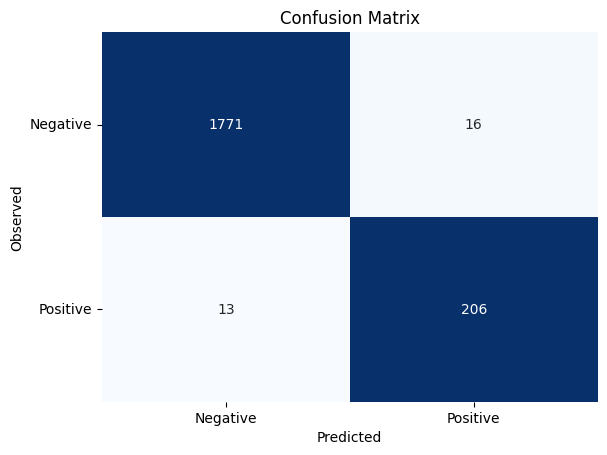

In [12]:
conf_mat       = confusion_matrix(y_test, bench_pred)
svm_mcc        = matthews_corrcoef(y_test, bench_pred)
svm_precision  = precision_score(y_test, bench_pred)
svm_sensitivity= recall_score(y_test, bench_pred)
svm_accuracy   = accuracy_score(y_test, bench_pred)
print(f"Neural Network Metrics:\n"
      f"MCC = {svm_mcc}\nPrecision = {svm_precision}\n"
      f"Sensitivity = {svm_sensitivity}\nAccuracy = {svm_accuracy}")

sns.heatmap(conf_mat, annot=True, cmap="Blues", fmt="d", cbar=False, vmax=200)
plt.xlabel("Predicted"); plt.ylabel("Observed"); plt.title("Confusion Matrix")
plt.xticks(ticks=[0.5, 1.5], labels=["Negative", "Positive"])
plt.yticks(ticks=[0.5, 1.5], labels=["Negative", "Positive"], rotation=0)
plt.show()


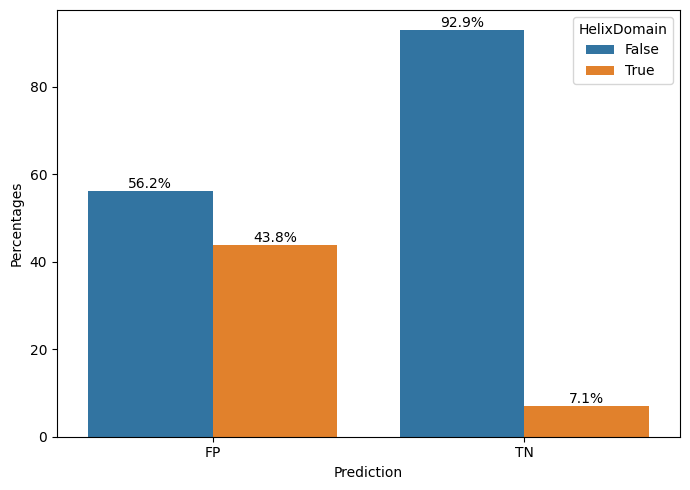

In [13]:
import os
os.makedirs("model_evaluation_DL", exist_ok=True)

# HelixDomain bar chart
counts = (prediction_dataset.groupby(["Prediction", "HelixDomain"])
          .size().rename("n").reset_index())
counts["percent"] = counts.groupby("Prediction")["n"].transform(
    lambda s: (s / s.sum()) * 100)

plt.figure(figsize=(7, 5))
ax = sns.barplot(data=counts, x="Prediction", y="percent", hue="HelixDomain")
ax.set_ylabel("Percentages"); ax.set_xlabel("Prediction")
ax.legend(title="HelixDomain")
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%")
plt.tight_layout()
plt.savefig("model_evaluation_DL/HD_prediction_1.png", dpi=300)
plt.show()


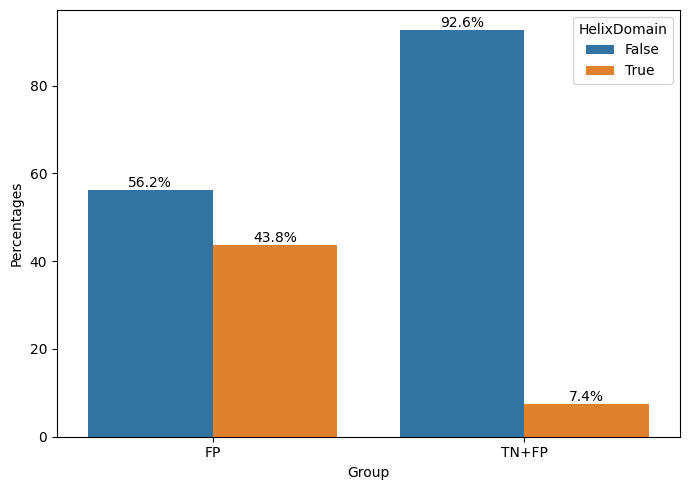

In [14]:
all_negatives = prediction_dataset.query("Class=='Negative'").copy()
all_negatives['Group'] = "TN+FP"
false_positive = prediction_dataset.query("Prediction=='FP'").copy()
false_positive['Group'] = "FP"
counts_group = pd.concat([false_positive, all_negatives], ignore_index=True)

counts = (counts_group.groupby(["Group", "HelixDomain"])
          .size().rename("n").reset_index())
counts["percent"] = counts.groupby("Group")["n"].transform(
    lambda s: (s / s.sum()) * 100)

plt.figure(figsize=(7, 5))
ax = sns.barplot(data=counts, x="Group", y="percent", hue="HelixDomain")
ax.set_ylabel("Percentages"); ax.set_xlabel("Group")
ax.legend(title="HelixDomain")
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%")
plt.tight_layout()
plt.savefig("model_evaluation_DL/HD_prediction_2.png", dpi=300)
plt.show()


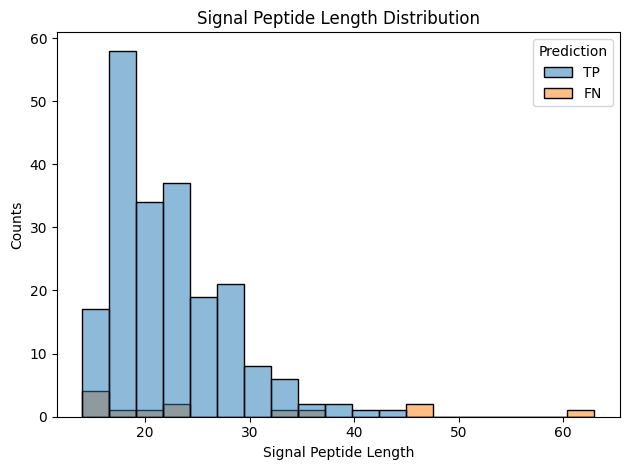

In [15]:
# FIX 3: sp_length must be computed from length_df itself, not from the
# full prediction_dataset (index mismatch → NaN for negative-class rows)
length_df = prediction_dataset.query("Class == 'Positive'").copy()
length_df["sp_length"] = length_df["SPEnd"] - length_df["SPStart"]  # fixed

sns.histplot(data=length_df, x="sp_length", hue="Prediction")
plt.title("Signal Peptide Length Distribution")
plt.ylabel("Counts"); plt.xlabel("Signal Peptide Length")
plt.tight_layout()
plt.savefig("model_evaluation_DL/Signalength_distribution.png", dpi=300)
plt.show()


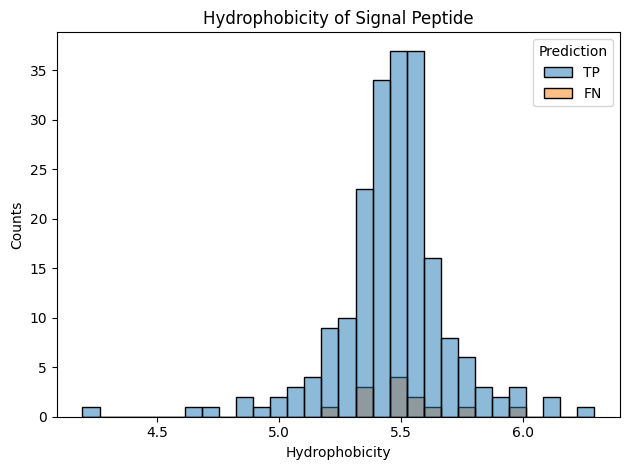

In [16]:
hydro_df = prediction_dataset.query("Class == 'Positive'").copy()
hydro_df["hydrophobicity"] = hydro_df.apply(
    lambda row: get_scale_features(
        row["Sequence"], "mi", int(row["SPEnd"] - row["SPStart"]), "mean"),
    axis=1)

sns.histplot(data=hydro_df, x="hydrophobicity", hue="Prediction")
plt.title("Hydrophobicity of Signal Peptide")
plt.ylabel("Counts"); plt.xlabel("Hydrophobicity")
plt.tight_layout()
plt.savefig("model_evaluation_DL/Hydrophobicity_SP.png", dpi=300)
plt.show()


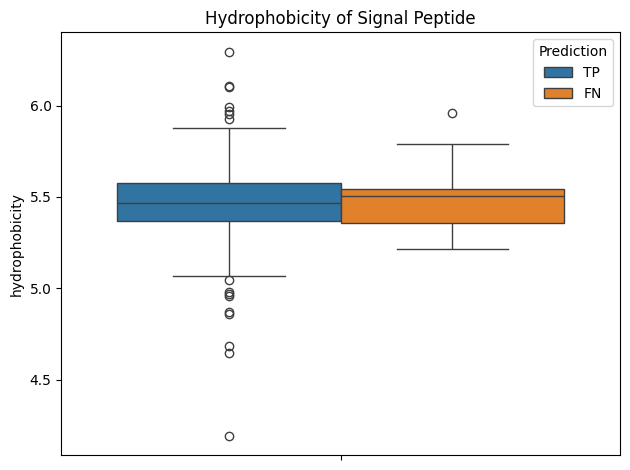

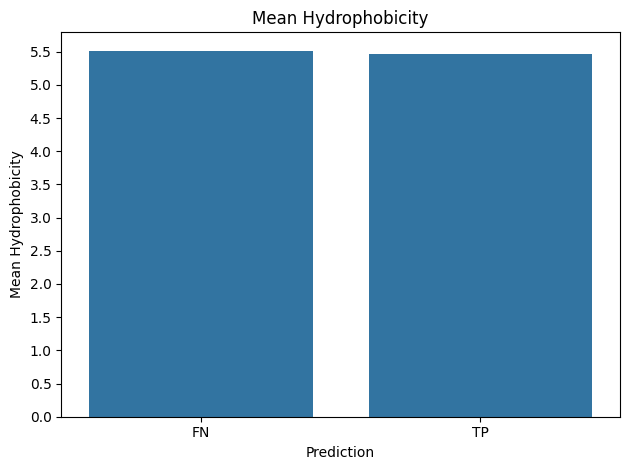


 Prediction
FN    5.515055
TP    5.464135
Name: hydrophobicity, dtype: float64 



In [17]:
sns.boxplot(data=hydro_df, y="hydrophobicity", hue="Prediction")
plt.title("Hydrophobicity of Signal Peptide")
plt.tight_layout()
plt.savefig("model_evaluation_DL/Boxplot_Hydrophobicity_SP.png", dpi=300)
plt.show()

hydro_means = hydro_df.groupby('Prediction')['hydrophobicity'].mean()
sns.barplot(x=hydro_means.index, y=hydro_means.values)
plt.ylabel("Mean Hydrophobicity")
plt.yticks([i / 10 for i in range(0, 60, 5)])
plt.title("Mean Hydrophobicity")
plt.tight_layout()
plt.savefig("model_evaluation_DL/Mean_hydrophobicity.png", dpi=300)
plt.show()
print("\n", hydro_means, "\n")


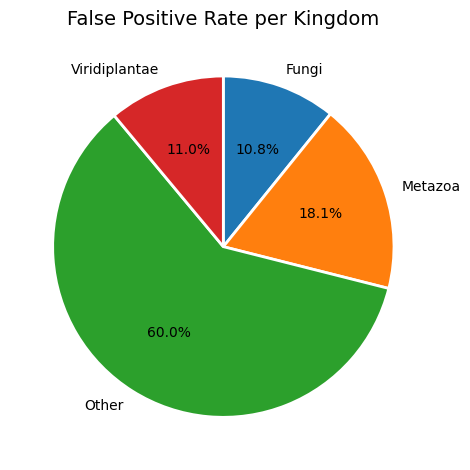

In [18]:
false_positives = prediction_dataset.query("Prediction=='FP'")
counts_falsepositive = (false_positives.groupby(["Kingdom", "Prediction"])
                        .size().rename("n").reset_index())
counts_falsepositive["total"] = counts_falsepositive["Kingdom"].map(
    benchmark.query("Class=='Negative'").groupby(["Kingdom"]).size())
counts_falsepositive["percent"] = counts_falsepositive.groupby("Kingdom")["n"].transform(
    lambda s: (s / counts_falsepositive["total"]) * 100)

fig, ax = plt.subplots()
ax.pie(counts_falsepositive["percent"],
       labels=counts_falsepositive["Kingdom"],
       autopct="%.1f%%", startangle=90, counterclock=False,
       wedgeprops={"linewidth": 2, "edgecolor": "white"})
ax.set_title("False Positive Rate per Kingdom", fontsize=14)
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("model_evaluation_DL/FPR_Kingdom.png", dpi=300)
plt.show()


In [19]:
fpr_svm       = len(false_positives) / len(benchmark.query("Class=='Negative'"))
fpr_helix_svm = (len(false_positive.query("HelixDomain==True")) /
                 len(benchmark.query("Class=='Negative' and HelixDomain==True")))
print("FPR Neural Network:", fpr_svm)
print("FPR Neural Network (transmembrane only):", fpr_helix_svm)


FPR Neural Network: 0.008953553441522105
FPR Neural Network (transmembrane only): 0.05303030303030303


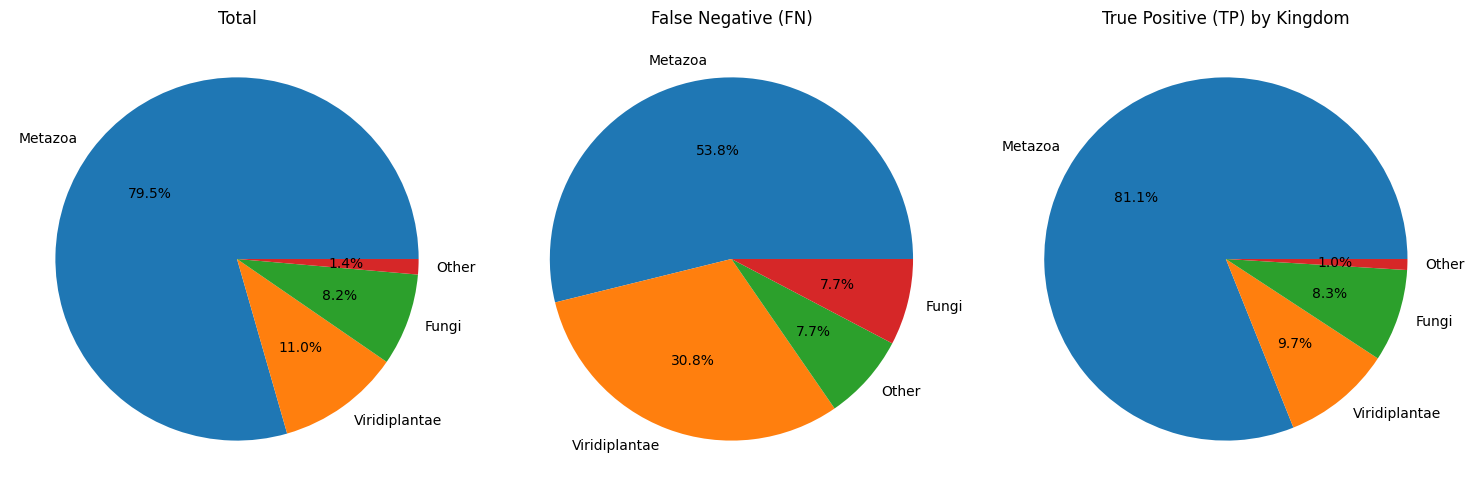

In [20]:
# Taxonomic composition of FN / FP / total
taxa_df     = prediction_dataset.query("Class == 'Positive'").copy()
counts_total = taxa_df['Kingdom'].value_counts()
counts_fn    = taxa_df[taxa_df['Prediction'] == 'FN']['Kingdom'].value_counts()
counts_fp    = taxa_df[taxa_df['Prediction'] == 'TP']['Kingdom'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].pie(counts_total, labels=counts_total.index, autopct='%1.1f%%')
axes[0].set_title('Total')
axes[1].pie(counts_fn, labels=counts_fn.index, autopct='%1.1f%%')
axes[1].set_title('False Negative (FN)')
axes[2].pie(counts_fp, labels=counts_fp.index, autopct='%1.1f%%')
axes[2].set_title('True Positive (TP) by Kingdom')
plt.tight_layout()
plt.savefig("model_evaluation_DL/Pieplot_species.png", dpi=300)
plt.show()


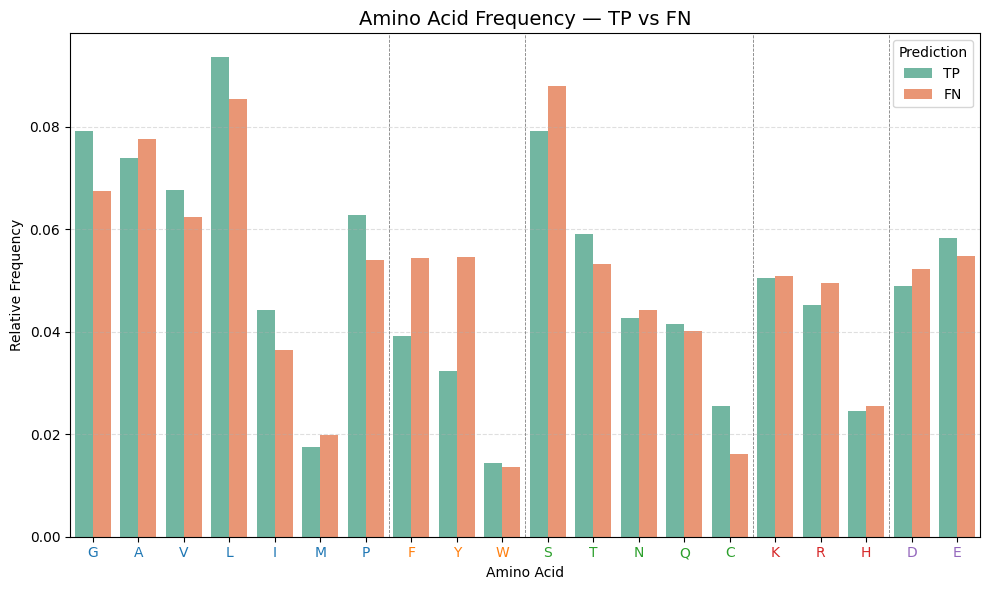

In [21]:
# Amino acid frequency comparison — TP vs FN
TP_df_sequence = prediction_dataset[prediction_dataset["Prediction"] == "TP"][["Sequence"]].copy()
FN_df_sequence = prediction_dataset[prediction_dataset["Prediction"] == "FN"][["Sequence"]].copy()

def aa_frequency(df):
    all_seq = "".join(df["Sequence"])
    total   = len(all_seq)
    return pd.Series({aa: all_seq.count(aa) / total for aa in set(all_seq)}).sort_index()

TP_freq = aa_frequency(TP_df_sequence)
FN_freq = aa_frequency(FN_df_sequence)

aa_categories = {
    'nonpolar': list("GAVLIMP"), 'aromatic': list("FYW"),
    'polar':    list("STNQC"),   'positive': list("KRH"),
    'negative': list("DE"),
}
aa_order = ['G','A','V','L','I','M','P','F','Y','W','S','T','N','Q','C','K','R','H','D','E']
cat_colors = {'nonpolar':'#1f77b4','aromatic':'#ff7f0e','polar':'#2ca02c',
              'positive':'#d62728','negative':'#9467bd'}
res_to_cat  = {aa: cat for cat, aas in aa_categories.items() for aa in aas}

aa_compare = (pd.DataFrame({"TP": TP_freq, "FN": FN_freq}).fillna(0)
              .reset_index()
              .melt(id_vars="index", var_name="Group", value_name="Frequency")
              .rename(columns={"index": "AminoAcid"}))
aa_compare["AminoAcid"] = pd.Categorical(aa_compare["AminoAcid"],
                                          categories=aa_order, ordered=True)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=aa_compare, x="AminoAcid", y="Frequency",
                 hue="Group", order=aa_order, palette="Set2")
ax.set_title("Amino Acid Frequency — TP vs FN", fontsize=14)
ax.set_xlabel("Amino Acid"); ax.set_ylabel("Relative Frequency")
ax.grid(axis='y', linestyle="--", alpha=0.4); ax.legend(title="Prediction")
for label in ax.get_xticklabels():
    cat = res_to_cat.get(label.get_text())
    if cat: label.set_color(cat_colors[cat])
current_cat = None
for i, aa in enumerate(aa_order):
    cat = res_to_cat[aa]
    if current_cat and cat != current_cat:
        ax.axvline(x=i - 0.5, color='gray', linestyle='--', linewidth=0.6)
    current_cat = cat
plt.tight_layout()
plt.savefig("model_evaluation_DL/AA_frequencies.png", dpi=300)
plt.show()


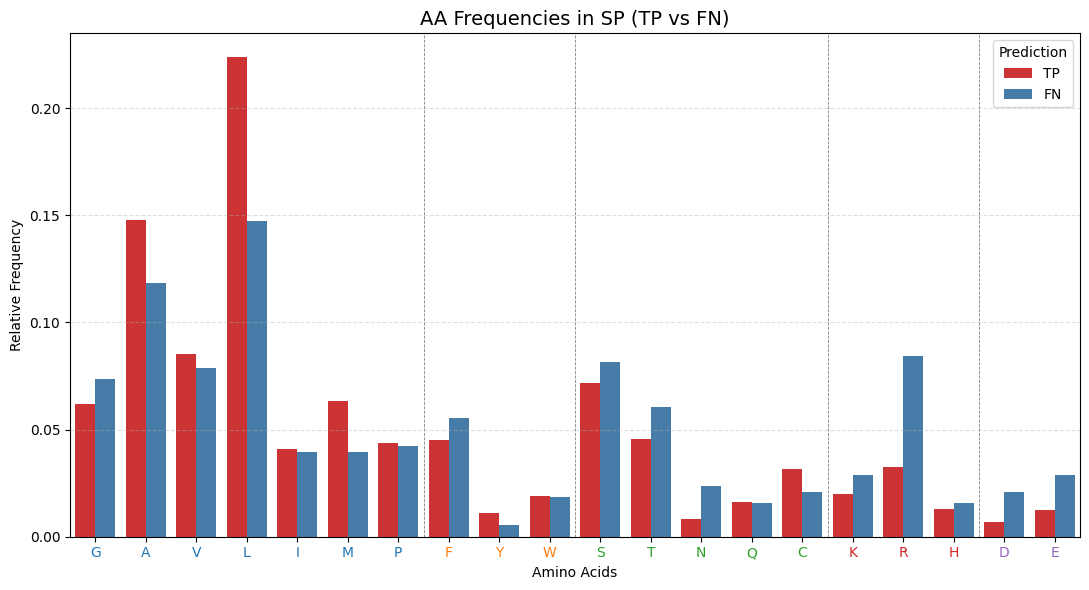

In [22]:
# Signal Peptide AA frequency — TP vs FN
SP_df = prediction_dataset[prediction_dataset["Prediction"].isin(["TP","FN"])][
    ["SPStart","SPEnd","Sequence","Prediction"]].copy()

def SP_aa_frequency(df):
    for index, row in df.iterrows():
        start = int(row["SPStart"]) - 1
        end   = int(row["SPEnd"])
        df.loc[index, "SPSequence"] = row["Sequence"][start:end]
    return df

SP_df = SP_aa_frequency(SP_df)

def SP_frequency(df, label):
    label_df = df[df["Prediction"] == label]
    all_seq  = "".join(label_df["SPSequence"].dropna().astype(str))
    total    = len(all_seq)
    if total == 0:
        return pd.Series(dtype=float)
    return pd.Series({aa: all_seq.count(aa) / total for aa in sorted(set(all_seq))})

sp_aa_compare = (pd.DataFrame({
    "TP": SP_frequency(SP_df, "TP"),
    "FN": SP_frequency(SP_df, "FN")
}).fillna(0).reset_index()
 .melt(id_vars="index", var_name="Group", value_name="Frequency")
 .rename(columns={"index": "AminoAcid"}))
sp_aa_compare["AminoAcid"] = pd.Categorical(sp_aa_compare["AminoAcid"],
                                              categories=aa_order, ordered=True)

plt.figure(figsize=(11, 6))
ax = sns.barplot(data=sp_aa_compare, x="AminoAcid", y="Frequency",
                 hue="Group", order=aa_order, palette="Set1")
ax.set_title("AA Frequencies in SP (TP vs FN)", fontsize=14)
ax.set_xlabel("Amino Acids"); ax.set_ylabel("Relative Frequency")
ax.grid(axis="y", linestyle="--", alpha=0.4); ax.legend(title="Prediction")
for tick in ax.get_xticklabels():
    cat = res_to_cat.get(tick.get_text())
    if cat: tick.set_color(cat_colors[cat])
current_cat = None
for i, aa in enumerate(aa_order):
    cat = res_to_cat[aa]
    if current_cat and cat != current_cat:
        ax.axvline(x=i - 0.5, color="gray", linestyle="--", linewidth=0.6, zorder=0)
    current_cat = cat
plt.tight_layout()
plt.savefig("model_evaluation_DL/AA_frequencies_SP.png", dpi=300)
plt.show()


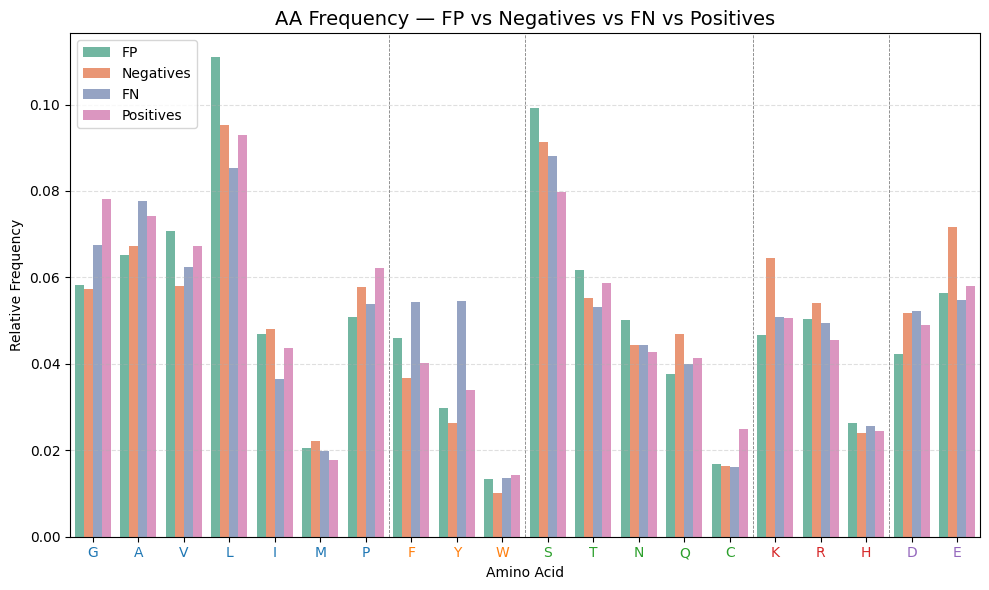

In [23]:
# All-groups AA frequency comparison
FP_df_sequence = prediction_dataset[prediction_dataset["Prediction"] == "FP"][["Sequence"]].copy()
PP_df_sequence = prediction_dataset[prediction_dataset["Class"] == "Positive"][["Sequence"]].copy()
NN_df_sequence = prediction_dataset[prediction_dataset["Class"] == "Negative"][["Sequence"]].copy()

FP_freq = aa_frequency(FP_df_sequence)
PP_freq = aa_frequency(PP_df_sequence)
NN_freq = aa_frequency(NN_df_sequence)

aa_compare_tot = (pd.DataFrame({
    "FP": FP_freq, "Negatives": NN_freq,
    "FN": FN_freq, "Positives": PP_freq
}).fillna(0).reset_index()
 .melt(id_vars="index", var_name="Group", value_name="Frequency")
 .rename(columns={"index": "AminoAcid"}))
aa_compare_tot["AminoAcid"] = pd.Categorical(aa_compare_tot["AminoAcid"],
                                               categories=aa_order, ordered=True)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=aa_compare_tot, x="AminoAcid", y="Frequency",
                 hue="Group", order=aa_order, palette="Set2")
ax.set_title("AA Frequency — FP vs Negatives vs FN vs Positives", fontsize=14)
ax.set_xlabel("Amino Acid"); ax.set_ylabel("Relative Frequency")
ax.grid(axis='y', linestyle="--", alpha=0.4); ax.legend()
for label in ax.get_xticklabels():
    cat = res_to_cat.get(label.get_text())
    if cat: label.set_color(cat_colors[cat])
current_cat = None
for i, aa in enumerate(aa_order):
    cat = res_to_cat[aa]
    if current_cat and cat != current_cat:
        ax.axvline(x=i - 0.5, color='gray', linestyle='--', linewidth=0.6)
    current_cat = cat
plt.tight_layout()
plt.savefig("model_evaluation_DL/AA_frequency_Distribution.png", dpi=300)
plt.show()


In [24]:
import logomaker as lm

logo_pos_seqs, logo_neg_seqs, logo_fn_seqs, logo_fp_seqs = [], [], [], []

logo_neg = prediction_dataset.query("Class == 'Negative'")
for _, row in logo_neg.iterrows():
    seq = row["Sequence"]
    logo_neg_seqs.append(seq[1:18])
    if row["Prediction"] == "FP":
        logo_fp_seqs.append(seq[1:18])

logo_pos = prediction_dataset.query("Class == 'Positive'")
for _, row in logo_pos.iterrows():
    seq = row["Sequence"]
    cp  = int(row["SPEnd"])
    logo_pos_seqs.append(seq[cp - 13: cp + 4])
    if row["Prediction"] == "FN":
        logo_fn_seqs.append(seq[cp - 13: cp + 4])

logo_fullseqs = [logo_pos_seqs, logo_fn_seqs, logo_neg_seqs, logo_fp_seqs]
labels        = ["True Positives", "False Negatives", "True Negatives", "False Positives"]


Sequence Logos — metric: information


<Figure size 600x1400 with 0 Axes>

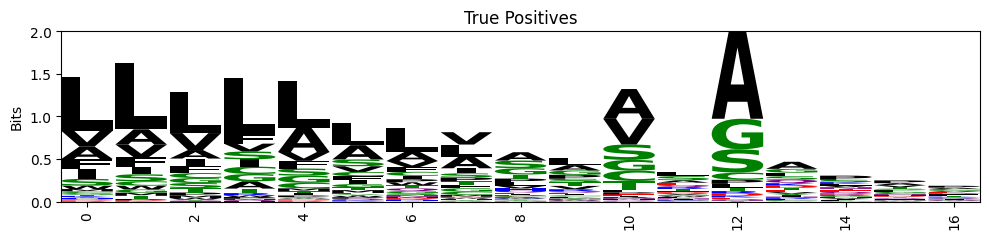

<Figure size 600x1400 with 0 Axes>

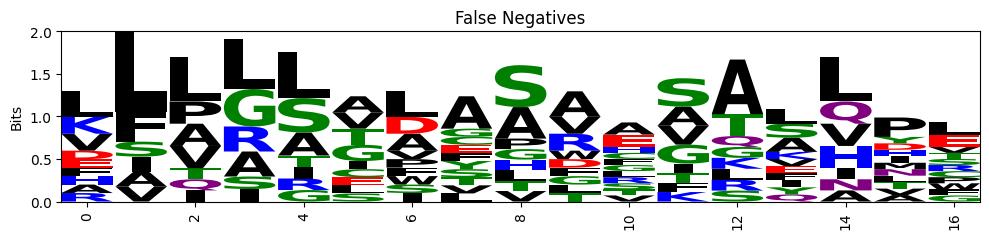

<Figure size 600x1400 with 0 Axes>

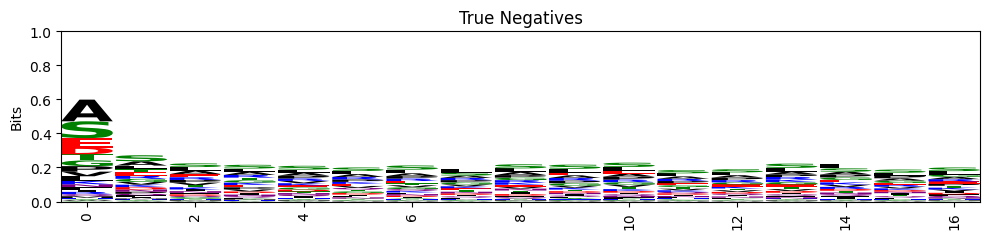

<Figure size 600x1400 with 0 Axes>

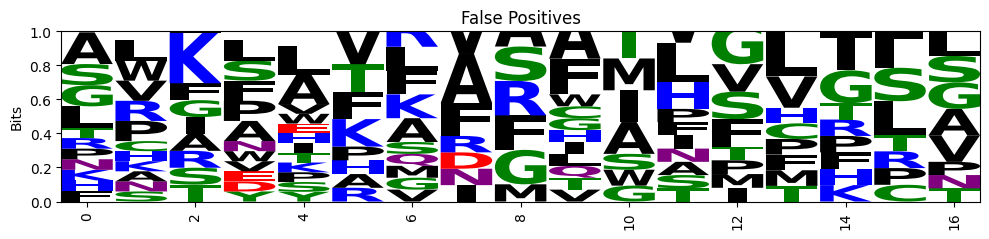

Sequence Logos — metric: probability


<Figure size 600x1400 with 0 Axes>

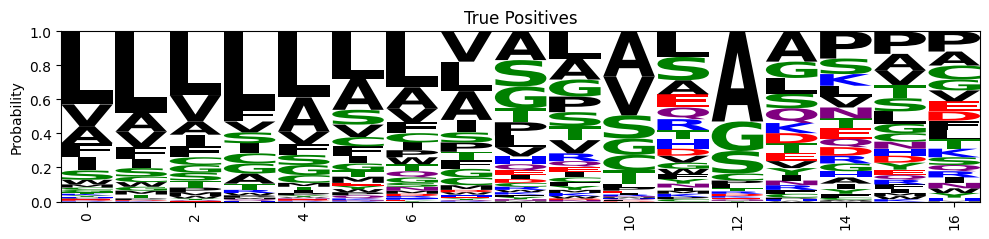

<Figure size 600x1400 with 0 Axes>

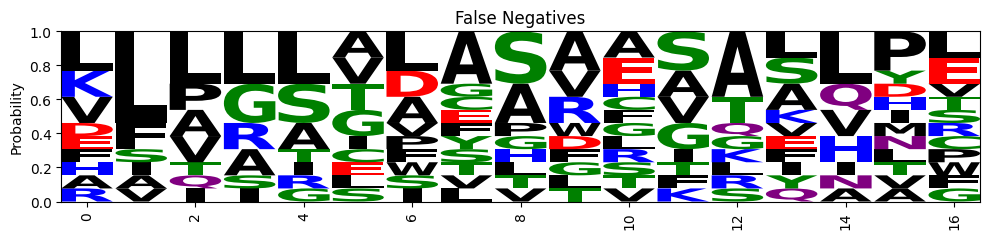

<Figure size 600x1400 with 0 Axes>

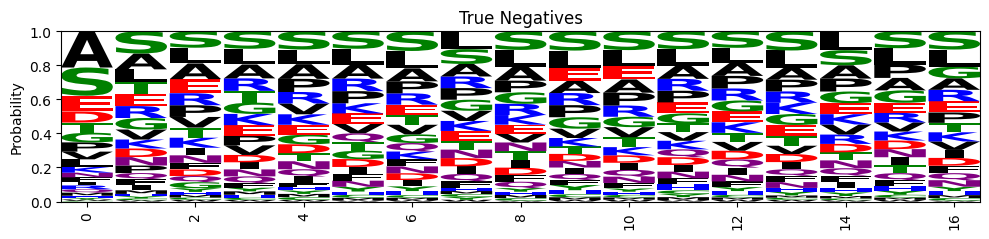

<Figure size 600x1400 with 0 Axes>

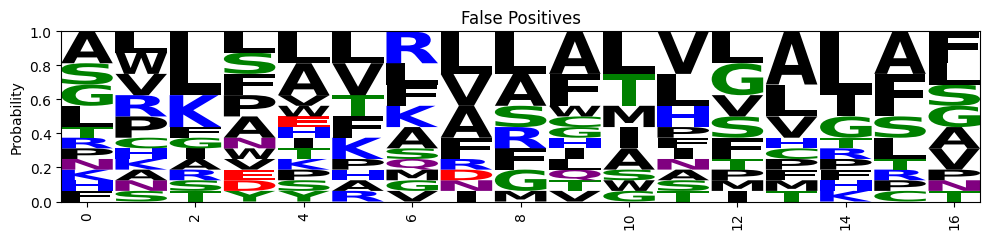

In [25]:
os.makedirs("model_evaluation_DL", exist_ok=True)

for metric, fname_prefix in [("information", "figure12A"), ("probability", "Sequence_Logo")]:
    print(f"Sequence Logos — metric: {metric}")
    for count, (seqs, label) in enumerate(zip(logo_fullseqs, labels), 1):
        logo_mat = lm.alignment_to_matrix(sequences=seqs, to_type=metric,
                                          characters_to_ignore='.-X', pseudocount=0)
        plt.figure(figsize=(6, 14))
        lm.Logo(logo_mat, shade_below=.5, fade_below=.5, color_scheme="chemistry")
        plt.xticks(rotation=90); plt.ylabel("Bits" if metric == "information" else "Probability")
        if label in ["True Negatives", "False Positives"]:
            plt.ylim(0, 1.0)
        elif metric == "information":
            plt.ylim(0, 2.0)
        plt.title(label)
        plt.tight_layout()
        plt.savefig(f"model_evaluation_DL/{fname_prefix}-{count}.png", dpi=300)
        plt.show()


In [26]:
# Viridiplantae / Arabidopsis FPR analysis
plant_df = prediction_dataset.query("Kingdom == 'Viridiplantae'")
print("FPR in plant entries:",
      plant_df.query("Prediction == 'FP'").shape[0] /
      plant_df.query("Class == 'Negative'").shape[0])
print("FPR in entire benchmark set:", fpr_svm)
print("\nTotal plant entries:", plant_df.shape[0])
print("Of which Arabidopsis thaliana:",
      plant_df.query("OrganismName == 'Arabidopsis thaliana'").shape[0])

fpr_ara = (plant_df.query("OrganismName == 'Arabidopsis thaliana' and Prediction == 'FP'").shape[0] /
           plant_df.query("OrganismName == 'Arabidopsis thaliana' and Class == 'Negative'").shape[0])
print("FPR in Arabidopsis entries:", fpr_ara)

fpr_not = (plant_df.query("OrganismName != 'Arabidopsis thaliana' and Prediction == 'FP'").shape[0] /
           plant_df.query("OrganismName != 'Arabidopsis thaliana' and Class == 'Negative'").shape[0])
print("FPR in all other plant entries:", fpr_not)


FPR in plant entries: 0.006349206349206349
FPR in entire benchmark set: 0.008953553441522105

Total plant entries: 339
Of which Arabidopsis thaliana: 243
FPR in Arabidopsis entries: 0.0
FPR in all other plant entries: 0.02702702702702703
